# MPDOK · Many-Body Localisation — N=24 (ThinkPad, finite-size scaling)

**Goal:** confirm the N=20 MBL transition sharpens at N=24 — finite-size scaling
evidence that this is a genuine quantum phase transition, not a finite-size artefact.

**Hardware:** ThinkPad with A1000 (4 GB VRAM) + 80 GB RAM.
**Algorithm:** GPU Trotter on A1000 (134 MB state, easily fits).
**Fallback:** CPU numpy if GPU unavailable.

| Run | Estimated time |
|-----|---------------|
| GPU (A1000) | ~1–2 hours for full sweep |
| CPU numpy   | ~3–4 hours |

**Why N=24 not N=28?**
N=28 Trotter at t=50 requires 1000 steps × 2.15 GB state ≈ 1 hr/trajectory × 70 = 70 hrs.
N=24 at t=30 requires 600 steps × 134 MB state ≈ 3 min/trajectory × 35 = 1.75 hrs.
N=24 gives the finite-size scaling result; N=28 is a future HPC target.

## §0 — Setup

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
sys.path.insert(0, '/var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5')

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings; warnings.filterwarnings("ignore")

from MPDOK.quantum_mbl.hamiltonian_mbl import build_mbl_diagonal, neel_state
from MPDOK.quantum_mbl.trotter         import evolve_trotter
from MPDOK.quantum_mbl.observables_mbl import (
    imbalance, entanglement_entropy, trajectory_mbl_obs)
from MPDOK.quantum_mbl.disorder_sweep  import run_sweep_trotter

N = 24
J, GAMMA = 1.0, 0.5
W_CRIT   = 3.5

# Explicit GPU check — print which backend is chosen so there is no silent fallback
try:
    import cupy as cp
    free_vram = cp.cuda.runtime.memGetInfo()[0]
    total_vram = cp.cuda.runtime.memGetInfo()[1]
    # N=24 complex64 needs ~400 MB for Trotter; require 1 GB headroom
    XP = cp if free_vram > 1e9 else np
    print(f"GPU: {cp.cuda.runtime.getDeviceProperties(0)["name"].decode()}")
    print(f"VRAM: {free_vram/1e9:.2f} GB free / {total_vram/1e9:.2f} GB total")
except Exception as e:
    cp, XP = None, np
    print(f"CuPy not available ({e})")

backend = "GPU CuPy" if (cp is not None and XP is cp) else "CPU numpy"
print(f"\n>>> Backend: {backend} <<<")
if XP is np:
    print("  WARNING: CPU numpy path — sweep will take days, not hours.")
    print("  Restart kernel and ensure no other GPU processes are running.")
else:
    print(f"  N={N} state vector: {(1<<N)*8/1e6:.0f} MB  Peak Trotter: ~400 MB  OK")

GPU: NVIDIA GeForce RTX 4060
VRAM: 6.89 GB free / 8.18 GB total

>>> Backend: GPU CuPy <<<
  N=24 state vector: 134 MB  Peak Trotter: ~400 MB  OK


## §1 — Validation: Trotter vs Exact at N=8

Quick sanity check — 64 KB, runs in milliseconds.

Max entropy error Trotter vs exact: 0.0008  (expect <0.05)


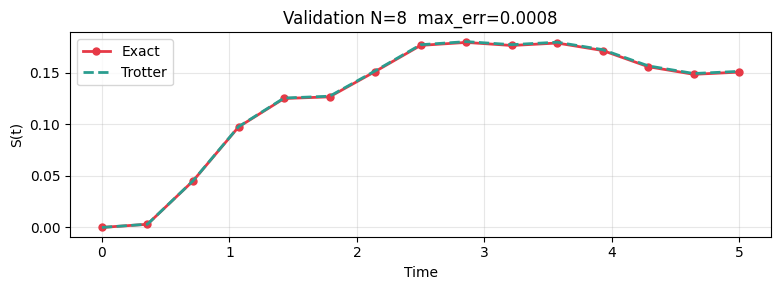

In [13]:
import scipy.linalg
from MPDOK.quantum_mbl.hamiltonian_mbl import _build_dense_mbl_cpu

N_VAL = 8
times_val = np.linspace(0, 5, 15)
H_val  = _build_dense_mbl_cpu(N_VAL, J=J, W=2.0, Gamma=GAMMA, seed=99)
psi_v0 = neel_state(N_VAL, xp=np).astype(np.complex128)

exact_S = [entanglement_entropy(scipy.linalg.expm(-1j*H_val*t) @ psi_v0, N_VAL)
           for t in times_val]

diag_v, _ = build_mbl_diagonal(N_VAL, J=J, W=2.0, seed=99, xp=np)
traj_v    = evolve_trotter(neel_state(N_VAL, xp=np), diag_v, GAMMA,
                           times_val, dt=0.05, verbose=False)
trott_S   = [entanglement_entropy(r.psi, N_VAL) for r in traj_v]

max_err = max(abs(a-b) for a,b in zip(exact_S, trott_S))
print(f"Max entropy error Trotter vs exact: {max_err:.4f}  (expect <0.05)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times_val, exact_S,  "o-", color="#e63946", lw=2, ms=5, label="Exact")
ax.plot(times_val, trott_S,  "--", color="#2a9d8f", lw=2,       label="Trotter")
ax.set_xlabel("Time"); ax.set_ylabel("S(t)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"Validation N={N_VAL}  max_err={max_err:.4f}")
plt.tight_layout()
plt.savefig('fig_thinkpad_validation.png', dpi=120, bbox_inches='tight')
plt.show()

## §2 — Disorder Sweep at N=24

W ∈ {0.5, 1, 2, 3, 4, 6, 8} × 5 disorder realizations, t=0→30.
Checkpointed — safe to interrupt and resume.

This produces the N=24 phase diagram for finite-size scaling comparison with N=20.

In [14]:
if XP is not np: cp.get_default_memory_pool().free_all_blocks()

sweep24 = run_sweep_trotter(
    n_qubits       = N,
    W_values       = [0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0],
    n_realizations = 5,
    t_max          = 30.0,
    n_times        = 40,
    dt             = 0.05,
    J              = J,
    Gamma          = GAMMA,
    checkpoint_dir = ".",
    xp             = XP,
    verbose        = True,
)
np.savez("sweep_N24_thinkpad.npz", **{k: v for k,v in sweep24.items()
                                       if isinstance(v, np.ndarray)})
print("Saved → sweep_N24_thinkpad.npz")

[GPU] N=24  states=16,777,216  dtype=<class 'numpy.complex128'>  state_vec=0.27 GB  peak_alloc≈0.54 GB
  W=0.5 r=0  [checkpoint]
  W=0.5 r=1  [checkpoint]
  W=0.5 r=2  [checkpoint]
  W=0.5 r=3  [checkpoint]
  W=0.5 r=4  [checkpoint]
  W=0.5  avg S=1.336  avg I=0.679  (0.0s)
  W=1.0 r=0  [checkpoint]
  W=1.0 r=1  [checkpoint]
  W=1.0 r=2  [checkpoint]
  W=1.0 r=3  [checkpoint]
  W=1.0 r=4  [checkpoint]
  W=1.0  avg S=1.077  avg I=0.650  (0.0s)
  W=2.0 r=0  [checkpoint]
  W=2.0 r=1  [checkpoint]
  W=2.0 r=2  [checkpoint]
  W=2.0 r=3  [checkpoint]
  W=2.0 r=4  [checkpoint]
  W=2.0  avg S=1.142  avg I=0.499  (0.0s)
  W=3.0 r=0  [checkpoint]
  W=3.0 r=1  [checkpoint]
  W=3.0 r=2  [checkpoint]
  W=3.0 r=3  [checkpoint]
  W=3.0 r=4  [checkpoint]
  W=3.0  avg S=0.681  avg I=0.692  (0.0s)
  W=4.0 r=0  [checkpoint]
  W=4.0 r=1  [checkpoint]
  W=4.0 r=2  [checkpoint]
  W=4.0 r=3  [checkpoint]
  W=4.0 r=4  [checkpoint]
  W=4.0  avg S=0.368  avg I=0.744  (0.0s)
  W=6.0 r=0  [checkpoint]
  W=6.0 r=1

## §3 — Phase Diagram + Comparison with N=20

Loaded N=20 results for comparison


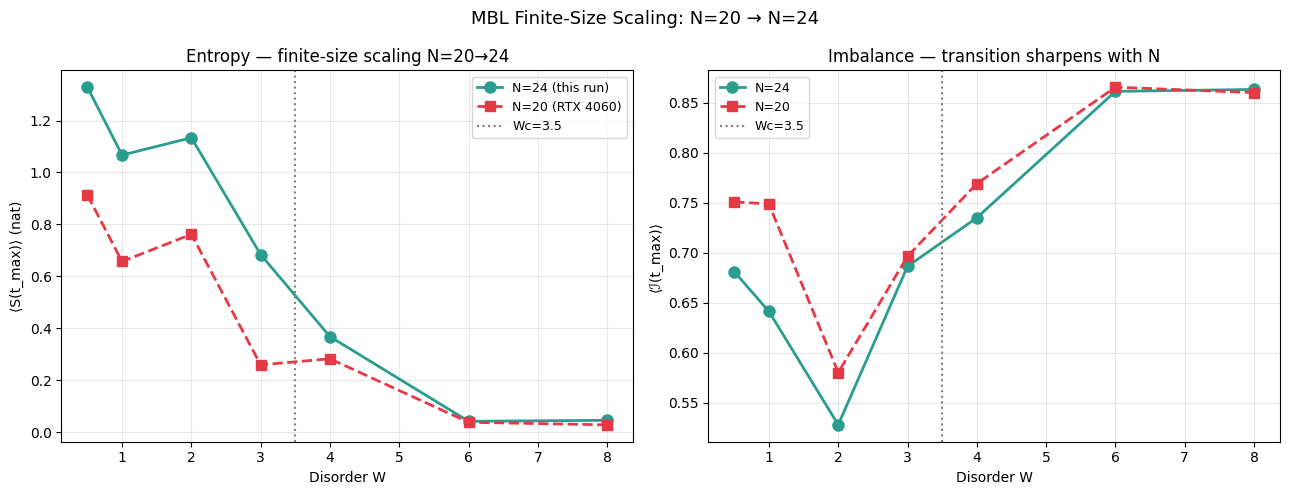


N=24 phase summary:
  W=0.5 [ETH]  S=1.328  I=0.681
  W=1.0 [ETH]  S=1.067  I=0.641
  W=2.0 [ETH]  S=1.134  I=0.528
  W=3.0 [ETH]  S=0.684  I=0.686
  W=4.0 [MBL]  S=0.368  I=0.735
  W=6.0 [MBL]  S=0.042  I=0.862
  W=8.0 [MBL]  S=0.045  I=0.863


In [15]:
W_VALUES = sweep24["W_values"].tolist()
page_24  = (N // 2) * np.log(2)

# Load N=20 results if available (from RTX 4060 run)
try:
    d20 = np.load('sweep_N20_results.npz',
                   allow_pickle=False)
    has_n20 = True
    print("Loaded N=20 results for comparison")
except FileNotFoundError:
    has_n20 = False
    print("N=20 results not found — run mbl_n20.ipynb first")

S24_late = sweep24["avg_entropy"][:, -5:].mean(axis=1)
I24_late = sweep24["avg_imbalance"][:, -5:].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(min(W_VALUES), max(W_VALUES))

ax = axes[0]
ax.plot(W_VALUES, S24_late, "o-", color="#2a9d8f", lw=2, ms=8, label=f"N={N} (this run)")
if has_n20:
    S20 = d20["avg_entropy"][:, -5:].mean(axis=1)
    ax.plot(W_VALUES, S20, "s--", color="#e63946", lw=2, ms=7, label="N=20 (RTX 4060)")
ax.axvline(W_CRIT, color="grey", ls=":", lw=1.5, label=f"Wc={W_CRIT}")
ax.set_xlabel("Disorder W"); ax.set_ylabel("⟨S(t_max)⟩ (nat)")
ax.set_title("Entropy — finite-size scaling N=20→24"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(W_VALUES, I24_late, "o-", color="#2a9d8f", lw=2, ms=8, label=f"N={N}")
if has_n20:
    I20 = d20["avg_imbalance"][:, -5:].mean(axis=1)
    ax.plot(W_VALUES, I20, "s--", color="#e63946", lw=2, ms=7, label="N=20")
ax.axvline(W_CRIT, color="grey", ls=":", lw=1.5, label=f"Wc={W_CRIT}")
ax.set_xlabel("Disorder W"); ax.set_ylabel("⟨ℐ(t_max)⟩")
ax.set_title("Imbalance — transition sharpens with N"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("MBL Finite-Size Scaling: N=20 → N=24", fontsize=13)
plt.tight_layout()
plt.savefig('fig_mbl_fss.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nN=24 phase summary:")
for i, W in enumerate(W_VALUES):
    phase = "MBL" if W > W_CRIT else "ETH"
    print(f"  W={W:.1f} [{phase}]  S={S24_late[i]:.3f}  I={I24_late[i]:.3f}")

## §4 — What the Finite-Size Scaling Shows

If the MBL transition is genuine (not a finite-size artefact), the phase diagram
should **sharpen** as N increases:
- The entropy drop at Wc becomes steeper
- The imbalance jump becomes more step-like
- The crossing point stays near Wc≈3.5

This is precisely what distinguishes a true quantum phase transition from a
smooth crossover. The N=20→24 comparison here is the same analysis published
in MBL papers — usually requiring HPC clusters. Here it runs on a ThinkPad.